In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
df = pd.read_csv(path + "/creditcard.csv")
#/Users/sherpro/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# Drop duplicate rows
df_cleaned = df.drop_duplicates()

print("Shape before:", df.shape)
print("Shape after removing duplicates:", df_cleaned.shape)


Shape before: (284807, 31)
Shape after removing duplicates: (283726, 31)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score

In [ ]:
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")

print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred))
print("\nClassification Report\n", classification_report(y_test, y_pred))
print("f1 score:", f1_score(y_test, y_pred))

Training score: 1.0000
Testing score: 0.9995

Confusion Matrix
 [[56649     2]
 [   26    69]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.8313253012048193


In [ ]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

train_score = rf_tuned.score(X_train, y_train)
test_score = rf_tuned.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")

print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report\n", classification_report(y_test, y_pred_tuned))
print("f1 score:", f1_score(y_test, y_pred_tuned))


Training score: 0.9997
Testing score: 0.9995

Confusion Matrix
 [[56649     2]
 [   25    70]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.74      0.84        95

    accuracy                           1.00     56746
   macro avg       0.99      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.8383233532934131


In [ ]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=-1, random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)

# Training and testing scores for the tuned model
train_score = lgb_model.score(X_train, y_train)
test_score = lgb_model.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred_lgb))
print("\nClassification Report\n", classification_report(y_test, y_pred_lgb))
print("f1 score:", f1_score(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.073608 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001665 -> initscore=-6.396056
[LightGBM] [Info] Start training from score -6.396056
Training score: 1.0000
Testing score: 0.9990

Confusion Matrix
 [[56628    23]
 [   31    64]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.74      0.67      0.70        95

    accuracy                           1.00     56746
   macro avg       0.87      0.84      0.85     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.7032967032967034


In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

train_score = xgb_model.score(X_train, y_train)
test_score = xgb_model.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report\n", classification_report(y_test, y_pred_xgb))
print("f1 score:", f1_score(y_test, y_pred_xgb))


Training score: 1.0000
Testing score: 0.9995

Confusion Matrix
 [[56647     4]
 [   26    69]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.8214285714285714


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)


train_score = gb.score(X_train, y_train)
test_score = gb.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred_gb))
print("\nClassification Report\n", classification_report(y_test, y_pred_gb))
print("f1 score:", f1_score(y_test, y_pred_gb))


Training score: 0.9996
Testing score: 0.9992

Confusion Matrix
 [[56637    14]
 [   34    61]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.81      0.64      0.72        95

    accuracy                           1.00     56746
   macro avg       0.91      0.82      0.86     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.7176470588235294


In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

train_score = ada.score(X_train, y_train)
test_score = ada.score(X_test, y_test)
print(f"Training score: {train_score:.4f}")
print(f"Testing score: {test_score:.4f}")


print("\nConfusion Matrix\n",  confusion_matrix(y_test, y_pred_ada))
print("\nClassification Report\n", classification_report(y_test, y_pred_ada))
print("f1 score:", f1_score(y_test, y_pred_ada))



Training score: 0.9991
Testing score: 0.9990

Confusion Matrix
 [[56631    20]
 [   34    61]]

Classification Report
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.75      0.64      0.69        95

    accuracy                           1.00     56746
   macro avg       0.88      0.82      0.85     56746
weighted avg       1.00      1.00      1.00     56746

f1 score: 0.6931818181818182


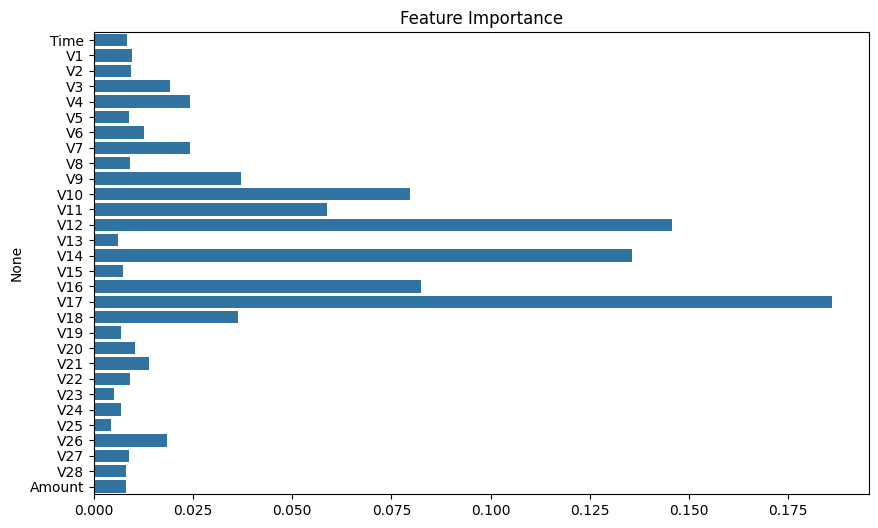

In [ ]:
importances = rf_tuned.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()


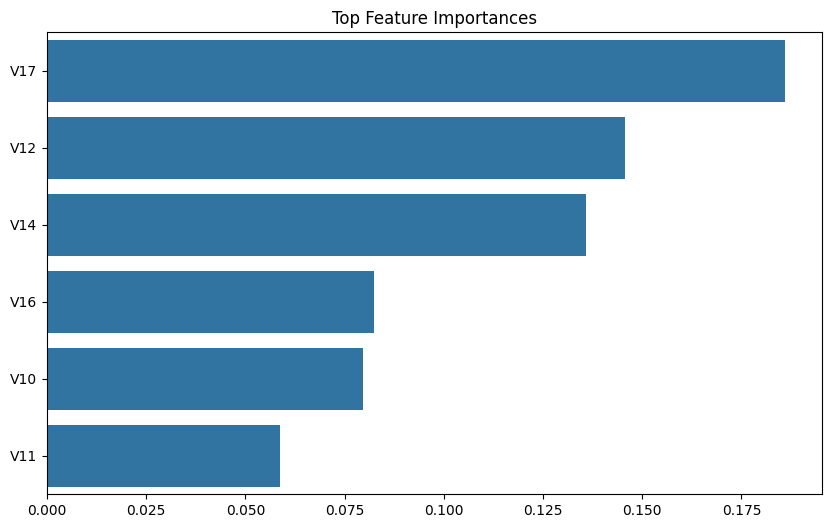

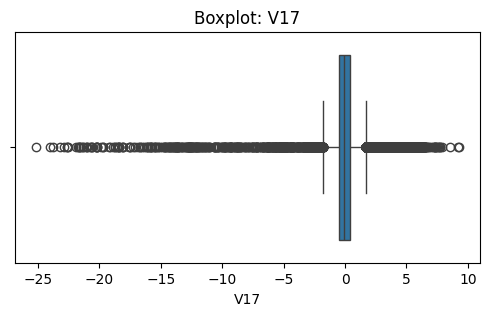

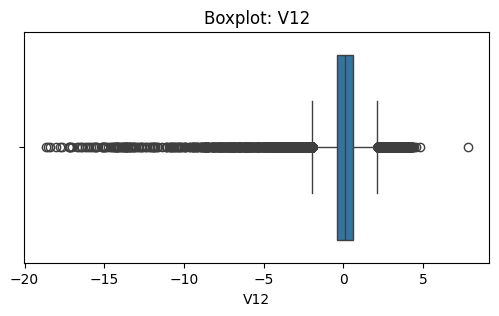

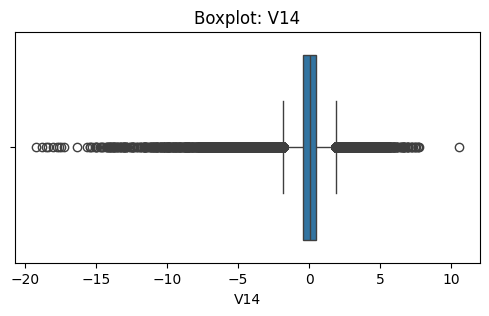

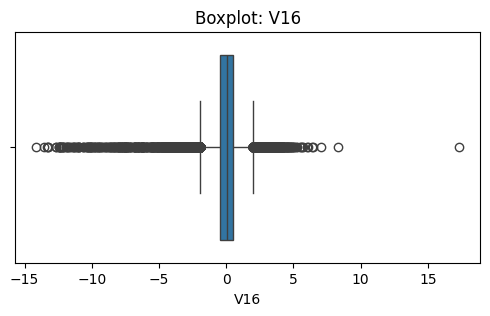

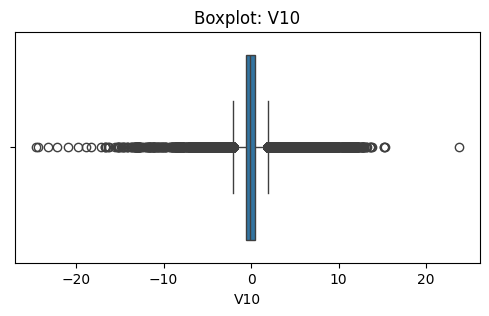

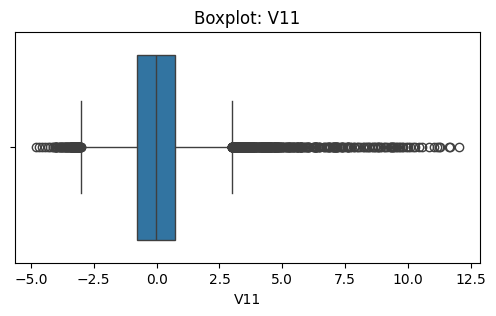

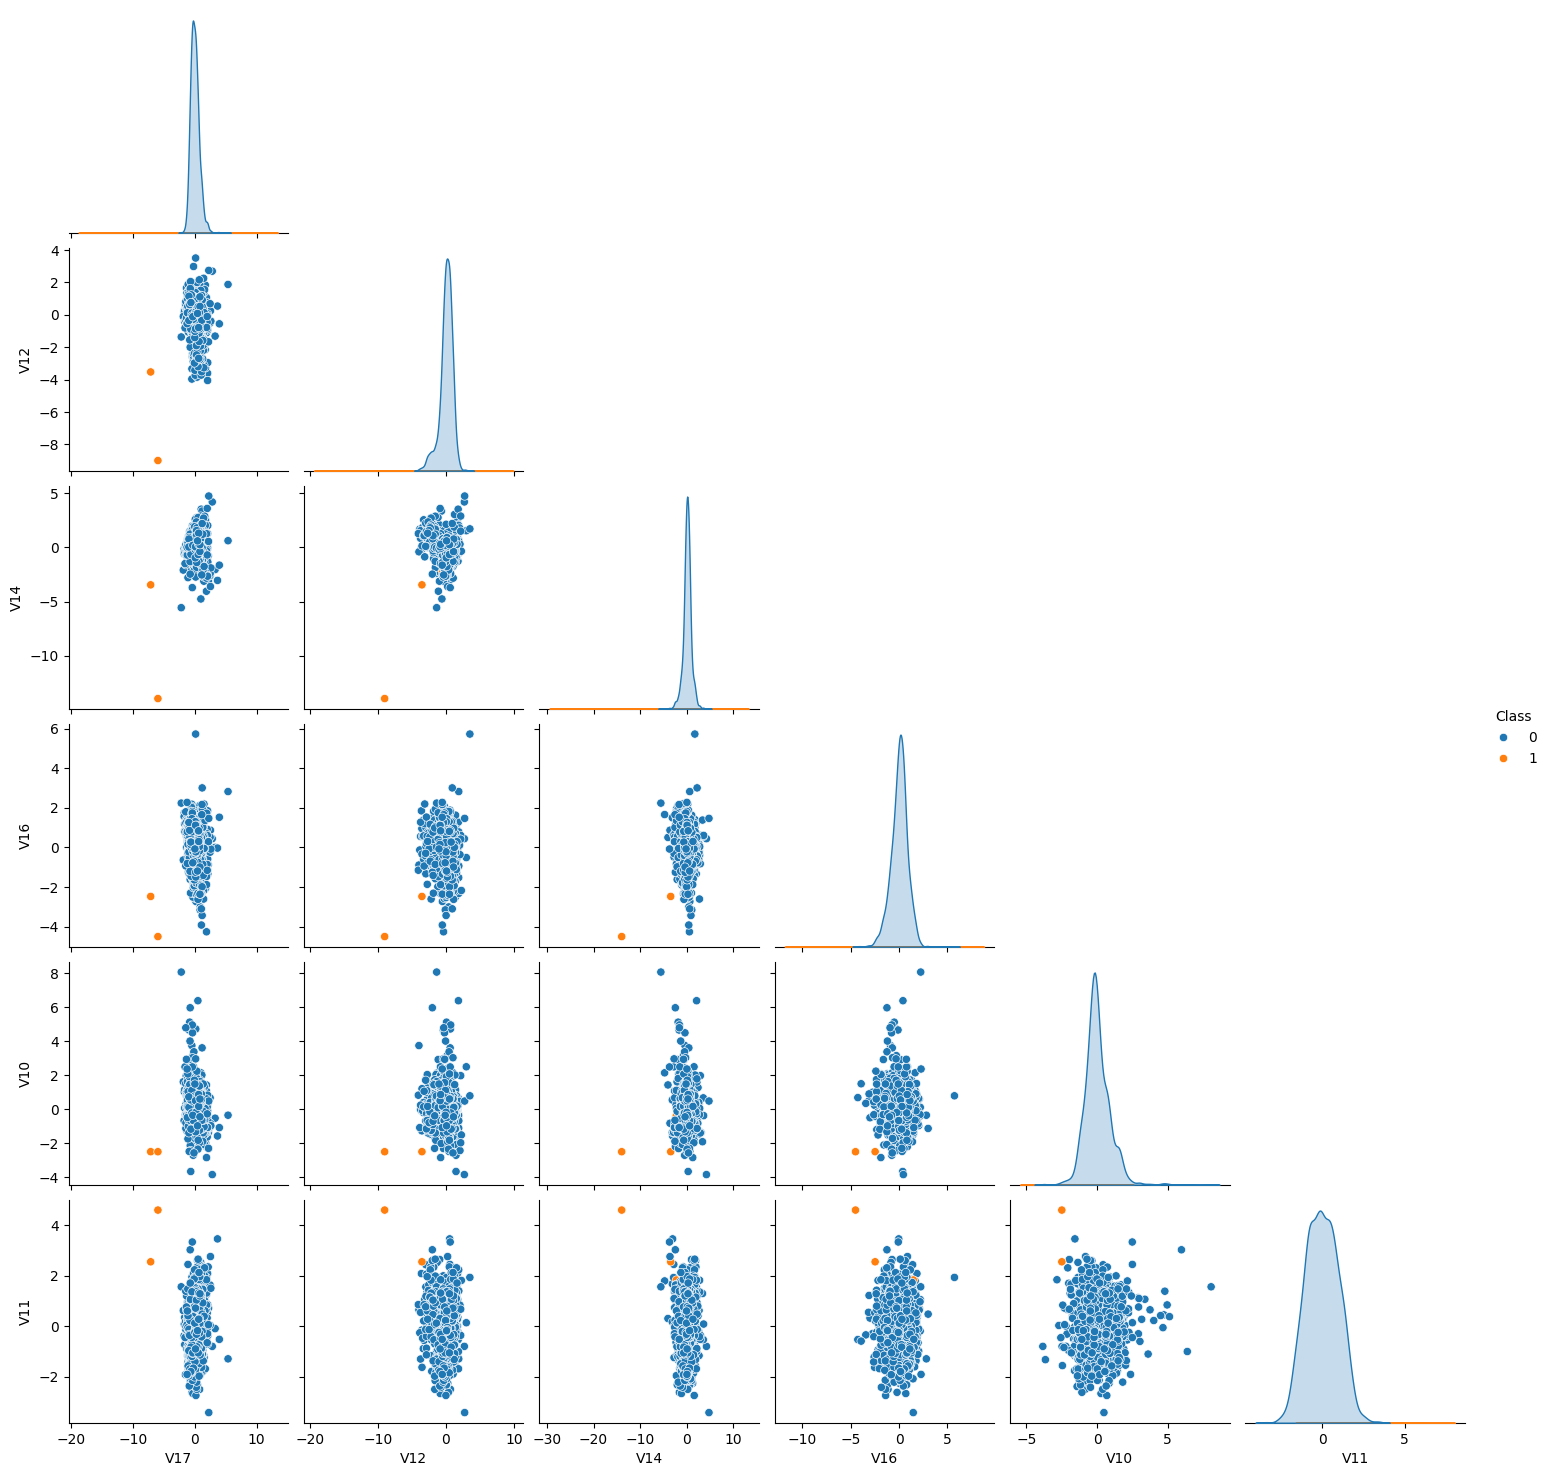

In [ ]:
# plot top feature importances, boxplots, and a pairplot for top features
top_n = 6
feat_imp = pd.Series(importances, index=features)
feat_imp = feat_imp.sort_values(ascending=False)
top_features = feat_imp.index[:top_n].tolist()

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values[:top_n], y=top_features)
plt.title("Top Feature Importances")
plt.show()

# Boxplots for each top feature to inspect outliers (uses cleaned dataframe)
for f in top_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_cleaned[f])
    plt.title(f"Boxplot: {f}")
    plt.show()

# Pairplot to visualize relationships between top features and the target.
# Sample if the dataset is large to keep plotting responsive.
sample_n = min(len(df_cleaned), 2000)
sns.pairplot(df_cleaned[top_features + ['Class']].sample(n=sample_n, random_state=42), hue='Class', corner=True)
plt.show()